Compilação de todas as bibliotecas

In [2]:
# bibliotecas
import csv
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_indicators

In [3]:
# path all files
ref = "drosophila_melanogaster_without_isoforms.tsv"
dm_kofam = "results/drosophila_melanogaster/kofamscan/drosophila_melanogaster.kofam.txt"
dm_pannzer2 = "results/drosophila_melanogaster/pannzer/PANNZER_resultado_Drosophila.txt"
dm_eggnog = 'results/drosophila_melanogaster/eggnog/drosophila_melanogaster_eggnog.emapper.annotations'
dm_interproscan = 'results/drosophila_melanogaster/interproscan/drosophila_melanogaster.interpro.tsv'

In [4]:
# Read the reference file
ref_dm = pd.read_csv(ref, sep="\t", header=None)

In [5]:
# Here we go trait starting with kofam results
dm_kofam_df = pd.read_csv(dm_kofam, sep="\t", dtype=str, comment="#", header=None, engine="python", quotechar='"')
# Here we go select only unique ID
dm_kofam_unique = dm_kofam_df.drop_duplicates(subset=[1], keep='first')
# We need select only the colummns with statistics diffence (*)
dm_kofam_unique_star = dm_kofam_unique[dm_kofam_unique[0].str.startswith("*", na=False)]
dm_kofam_unique_star_desc = dm_kofam_unique_star.drop(columns=[0, 2, 3, 4, 5]).rename(columns={1: "Protein_ID", 6: "Kofam"})
dm_kofam_unique_star_desc

,Protein_ID,Kofam
0,rna-NM_001103384.3,gamma-glutamyltranspeptidase / glutathione hyd...
5,rna-NM_001258512.2,gamma-glutamyltranspeptidase / glutathione hyd...
10,rna-NM_001258513.2,gamma-glutamyltranspeptidase / glutathione hyd...
475,rna-NM_130478.3,[histone H3]-lysine9 N-trimethyltransferase EH...
651,rna-NM_001272159.1,[histone H3]-lysine9 N-trimethyltransferase EH...
...,...,...
1858348,rna-NM_001015497.4,serine/threonine-protein phosphatase PP1 catal...
1858364,rna-NM_001015498.5,cilia- and flagella-associated protein 58
1858478,rna-NM_001110584.3,glycoprotein hormone alpha-2
1858484,rna-NM_001015101.2,kelch-like protein 10


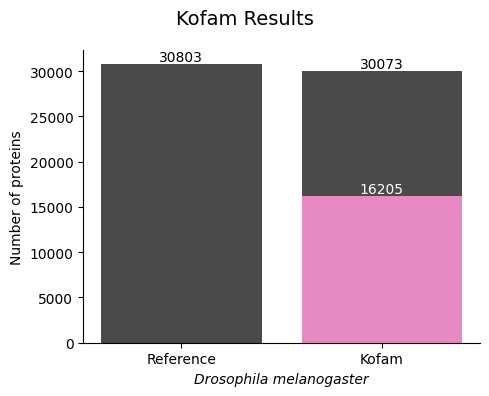

In [6]:
# Plot the results of kofam
# Colors
all_color = "#4a4a4a"
diff_color = "#e78ac3"
desc_color = "#66c2a5"
text = "#ffffff"

fig, ax = plt.subplots(figsize=(5, 4))
for loc, spine in ax.spines.items():
    if loc in ("bottom", "left"):
        spine.set_visible(True)
    else:
        spine.set_visible(False)

x_sac = ["Reference", "Kofam"]

# Plotar do maior para o menor ajuda a visualizar a sobreposição
ax.bar(x_sac[0], len(ref_dm[0]), color=all_color, label="All")
ax.bar(x_sac[1], len(dm_kofam_unique), color=all_color)
ax.bar(x_sac[1], len(dm_kofam_unique_star), color=diff_color, label="Significant")
ax.set_ylabel("Number of proteins")
ax.text(0, len(ref_dm[0]) + 5, str(len(ref_dm[0])), ha="center", va="bottom", fontsize=10)
ax.text(1, len(dm_kofam_unique) + 5, str(len(dm_kofam_unique)), ha="center", va="bottom", fontsize=10)
ax.text(1, len(dm_kofam_unique_star) + 5, str(len(dm_kofam_unique_star)), ha="center", va="bottom", fontsize=10, color=text)
ax.set_xlabel("Drosophila melanogaster", fontstyle="italic")
fig.suptitle("Kofam Results", fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
# Here we go trait pannzer2 results
dm_pannzer2_df = pd.read_csv(dm_pannzer2, sep="\t", dtype=str, comment="#", header=None, engine="python", quotechar='"')
# For select only unique ID, we need select for raw of the column 1 and select only have the term "DE"
dm_pannzer2_unique = dm_pannzer2_df[dm_pannzer2_df[1].str.contains("DE", na=False)]
dm_pannzer2_unique = dm_pannzer2_unique[~dm_pannzer2_unique[1].str.contains("original_DE", na=False)]
dm_pannzer2_unique_desc = dm_pannzer2_unique.drop(columns=[1, 2, 3, 4]).rename(columns={0: "Protein_ID", 5: "Pannzer2"})
dm_pannzer2_unique_desc

,Protein_ID,Pannzer2
3,rna-NM_001103384.3,Scoloptoxin SSD14
13,rna-NM_001258512.2,Scoloptoxin SSD14
30,rna-NM_001258513.2,Scoloptoxin SSD14
40,rna-NM_001297795.1,Active breakpoint cluster region-related protein
54,rna-NM_001297796.1,Active breakpoint cluster region-related protein
...,...,...
348554,rna-NM_001316660.1,Coiled-Coils Y
348558,rna-NM_001110608.2,Asparagine-rich protein-like isoform X1
348562,rna-NM_001110584.3,Thyrostimulin alpha-2 subunit
348575,rna-NM_001015101.2,Kelch-like protein diablo


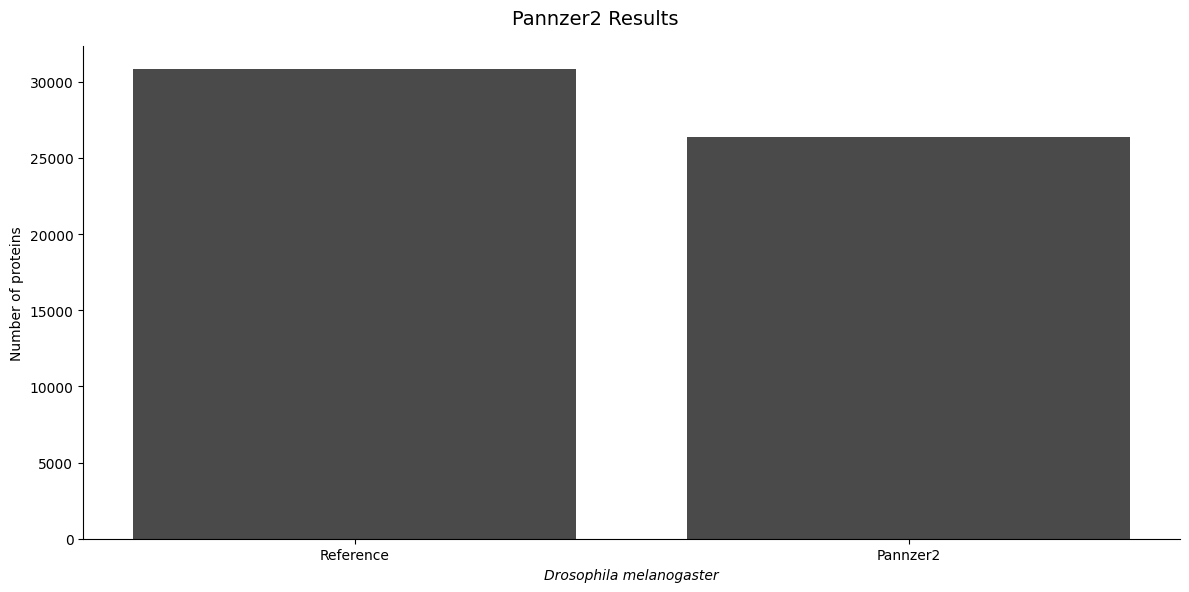

In [8]:
# Plot the results of pannzer2
fig, ax = plt.subplots(figsize=(12, 6))
for loc, spine in ax.spines.items():
    if loc in ("bottom", "left"):
        spine.set_visible(True)
    else:
        spine.set_visible(False)

x_sac = ["Reference", "Pannzer2"]

# Plotar do maior para o menor ajuda a visualizar a sobreposição
ax.bar(x_sac[0], len(ref_dm[0]), color=all_color, label="With description")
ax.bar(x_sac[1], len(dm_pannzer2_unique), color=all_color, label="Significant")

ax.set_ylabel("Number of proteins")
ax.set_xlabel("Drosophila melanogaster", fontstyle="italic")
fig.suptitle("Pannzer2 Results", fontsize=14)

plt.tight_layout()
plt.show()

In [9]:
# Here we go trait eggnog
dm_eggnog_df = pd.read_csv(dm_eggnog, sep="\t", dtype=str, comment="#", header=None, engine="python", quotechar='"')

dm_eggnog_wi = dm_eggnog_df.copy()
mask = dm_eggnog_df[7].str.startswith(("to Drosophila melanogaster", "Drosophila melanogaster"), na=False)
dm_eggnog_wi.loc[mask, 7] = "Without information"
dm_eggnog_wi_total = dm_eggnog_wi[dm_eggnog_wi[7] == "Without information"]

dm_eggnog_desc = dm_eggnog_df.drop(columns=[1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]).rename(columns={0: "Protein_ID", 7: "EggNOG"})
dm_eggnog_desc

,Protein_ID,EggNOG
0,rna-NM_001258652.1,Bravo-like intracellular region
1,rna-NM_001169239.2,"Domain always found downstream of DENN domain,..."
2,rna-NM_001272431.1,positive regulation of protein localization to...
3,rna-NM_001169243.3,It is involved in the biological process descr...
4,rna-NM_078540.5,Histone H3
...,...,...
28403,rna-NM_145106.1,DNA binding
28404,rna-NM_001169908.2,-
28405,rna-NM_176303.5,"Domain present in PSD-95, Dlg, and ZO-1/2."
28406,rna-NM_168294.3,Formin Homology 2 Domain


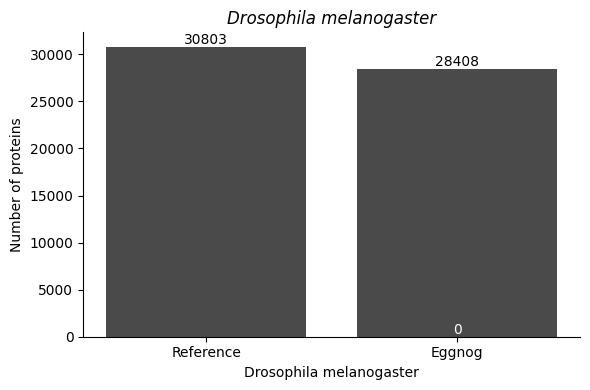

In [10]:
# Plot the results of eggnog
fig, ax = plt.subplots(figsize=(6, 4))
for loc, spine in ax.spines.items():
    if loc in ("bottom", "left"):
        spine.set_visible(True)
    else:
        spine.set_visible(False)

x_sac = ["Reference", "Eggnog"]

# Plotar do maior para o menor ajuda a visualizar a sobreposição
ax.bar(x_sac[0], len(ref_dm[0]), color=all_color)
ax.bar(x_sac[1], len(dm_eggnog_df[0]), color=all_color)
ax.bar(x_sac[1], len(dm_eggnog_wi_total[0]), color=diff_color, label="Without information")
ax.text(0, len(ref_dm[0]) + 5, str(len(ref_dm[0])), ha="center", va="bottom", fontsize=10)
ax.text(1, len(dm_eggnog_df[0]) + 5, str(len(dm_eggnog_df[0])), ha="center", va="bottom", fontsize=10)
ax.text(1, len(dm_eggnog_wi_total[0]) + 5, str(len(dm_eggnog_wi_total[0])), ha="center", va="bottom", fontsize=10, color=text)
ax.set_title("Drosophila melanogaster", fontstyle="italic")
ax.set_ylabel("Number of proteins")
ax.set_xlabel("Drosophila melanogaster")

plt.tight_layout()
plt.show()

In [11]:
# Here we go trait interproscan results
dm_interproscan_df = pd.read_csv(dm_interproscan, sep="\t", dtype=str, comment="#", header=None, engine="python", quoting=csv.QUOTE_NONE)

dm_interproscan_filtered = dm_interproscan_df.loc[dm_interproscan_df[3].str.contains("ANTHER|NCBIfam|SFLD|Hamap|PIRSF", na=False)]
dm_interproscan_filtered_final = dm_interproscan_filtered.loc[dm_interproscan_filtered.groupby(0)[8].idxmin()]
dm_interproscan_desc = dm_interproscan_filtered_final.drop(columns=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]).rename(columns={0: "Protein_ID", 12: "InterProScan"})
dm_interproscan_desc

,Protein_ID,InterProScan
172065,rna-NM_001007095.3,Cyclic nucleotide synthase
171915,rna-NM_001007096.3,Cyclic nucleotide synthase
370833,rna-NM_001014453.2,-
418193,rna-NM_001014454.2,-
418206,rna-NM_001014455.2,-
...,...,...
238857,rna-NM_206800.3,POPDC1-3
514932,rna-NM_206803.3,Proline oxidase family
514972,rna-NM_206804.3,Proline oxidase family
514912,rna-NM_206805.3,Proline oxidase family


/home/marymardegan/miniconda3/envs/upset_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/marymardegan/miniconda3/envs/upset_env/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on

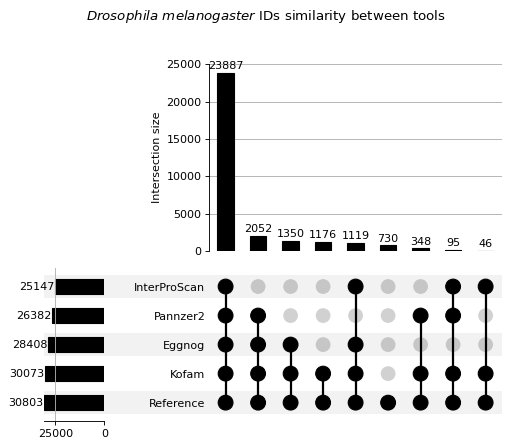

In [12]:
# aqui a gente vai pegar todas as df tratadas para unir 
df_ref = ref_dm[0].copy().to_frame(name="Protein_ID")
df_ref["Source"] = "Reference"
df_kofam = dm_kofam_unique[1].copy().to_frame(name="Protein_ID")
df_kofam["Source"] = "Kofam"
df_pannzer2 = dm_pannzer2_unique[0].copy().to_frame(name="Protein_ID")
df_pannzer2["Source"] = "Pannzer2"
df_eggnog = dm_eggnog_df[0].copy().to_frame(name="Protein_ID")
df_eggnog["Source"] = "Eggnog"
df_interpro = dm_interproscan_filtered_final[0].copy().to_frame(name="Protein_ID")
df_interpro["Source"] = "InterProScan"

# Concatenar os dataframes
sc_all = pd.concat([df_ref, df_kofam, df_pannzer2, df_eggnog, df_interpro], ignore_index=True)
sc_all

# UpSetPlot works very well with a presence/absence matrix
sc_upset = pd.crosstab(sc_all["Protein_ID"], sc_all["Source"]).astype(bool)
sc_upset

upset_data = from_indicators(sc_upset.columns, sc_upset)
upset = UpSet(
    upset_data,
    subset_size="count",
    show_counts="%d",
    sort_by="cardinality",
    sort_categories_by="cardinality",
    element_size=38
)

fig = plt.figure(figsize=(10, 6), dpi=80)
upset.plot(fig=fig)
fig.suptitle(r"$\it{Drosophila}$ $\it{melanogaster}$ IDs similarity between tools", y=1.0)
plt.show()

In [13]:
# Now we will concat all value of ID and description
df_informative = ref_dm.copy()
ref_desc = df_informative.iloc[1:].rename(columns={0: "Protein_ID", 1: "Reference"})

In [14]:
merge_all = pd.merge(ref_desc[["Protein_ID", "Reference"]], dm_kofam_unique_star_desc[["Protein_ID", "Kofam"]], how= "right", on="Protein_ID")
merge_all = pd.merge(merge_all, dm_pannzer2_unique_desc[["Protein_ID", "Pannzer2"]], how= "right", on="Protein_ID")
merge_all = pd.merge(merge_all, dm_eggnog_desc[["Protein_ID", "EggNOG"]], how= "right", on="Protein_ID")
merge_all = pd.merge(merge_all, dm_interproscan_desc[["Protein_ID", "InterProScan"]], how= "right", on="Protein_ID")

merge_all

,Protein_ID,Reference,Kofam,Pannzer2,EggNOG,InterProScan
0,rna-NM_001007095.3,NaN,NaN,Guanylate cyclase,phosphorus-oxygen lyase activity. It is involv...,Cyclic nucleotide synthase
1,rna-NM_001007096.3,NaN,NaN,Guanylate cyclase,phosphorus-oxygen lyase activity. It is involv...,Cyclic nucleotide synthase
2,rna-NM_001014453.2,phosphatase 1 nuclear targeting subunit,protein phosphatase 1 regulatory subunit 10,Serine/threonine-protein phosphatase 1 regulat...,metal ion binding. It is involved in the biolo...,-
3,rna-NM_001014454.2,phosphatase 1 nuclear targeting subunit,protein phosphatase 1 regulatory subunit 10,Nucleolar and coiled-body phosphoprotein 1 iso...,metal ion binding. It is involved in the biolo...,-
4,rna-NM_001014455.2,phosphatase 1 nuclear targeting subunit,protein phosphatase 1 regulatory subunit 10,Nucleolar and coiled-body phosphoprotein 1 iso...,metal ion binding. It is involved in the biolo...,-
...,...,...,...,...,...,...
25142,rna-NM_206800.3,bves,blood vessel epicardial substance,Blood vessel epicardial substance,Popeye protein conserved region,POPDC1-3
25143,rna-NM_206803.3,sluggish A,proline dehydrogenase [EC:1.5.5.2],Proline dehydrogenase,Converts proline to delta-1-pyrroline-5-carbox...,Proline oxidase family
25144,rna-NM_206804.3,sluggish A,proline dehydrogenase [EC:1.5.5.2],Proline dehydrogenase,Converts proline to delta-1-pyrroline-5-carbox...,Proline oxidase family
25145,rna-NM_206805.3,sluggish A,proline dehydrogenase [EC:1.5.5.2],Proline dehydrogenase,Converts proline to delta-1-pyrroline-5-carbox...,Proline oxidase family


In [15]:
def is_informative(product_text):
    if pd.isna(product_text):
        return False
       
    text = str(product_text).lower().strip()
   
    vague_terms = [
        'hypothetical',
        'uncharacterized',
        'unknown',
        'putative',
        'duf',
        'domain of unknown function'
    ]
   
    if any(term in text for term in vague_terms) or text == '':
        return False
   
    return True

merged_df = merge_all.copy()

tools = ['Reference', 'Kofam', 'Pannzer2', 'EggNOG', 'InterProScan']

for tool in tools:
    info_col = f'is_info_{tool}'
    merged_df[info_col] = merged_df[tool].apply(is_informative)

comparison_results = []
tools_to_evaluate = ['Kofam', 'EggNOG', 'Pannzer2', 'InterProScan']

for tool in tools_to_evaluate:
    tool_info = merged_df[f'is_info_{tool}']
    ref_info = merged_df['is_info_Reference']
   
    for i in range(len(merged_df)):
        t_val = tool_info.iloc[i]
        r_val = ref_info.iloc[i]
       
        if t_val == True and r_val == True:
            category = 'Both Informative'
        elif t_val == False and r_val == False:
            category = 'Both Hypothetical'
        elif t_val == True and r_val == False:
            category = 'Over-Annotation'
        elif t_val == False and r_val == True:
            category = 'Under-Annotation'
           
        comparison_results.append({
            'Tool': tool,
            'Category': category
        })

df_plot = pd.DataFrame(comparison_results)
summary_table = df_plot.groupby(['Tool', 'Category']).size().unstack(fill_value=0)

col_order = ['Both Informative', 'Both Hypothetical', 'Over-Annotation', 'Under-Annotation']
summary_table = summary_table.reindex(columns=col_order, fill_value=0)

print("--- Functional Summary: Tool vs Reference ---")
display(summary_table)

--- Functional Summary: Tool vs Reference ---


Category,Both Informative,Both Hypothetical,Over-Annotation,Under-Annotation
Tool,,,,
EggNOG,12248,730,12021,148
InterProScan,12391,200,12551,5
Kofam,12390,9707,3044,6
Pannzer2,12091,1578,11173,305


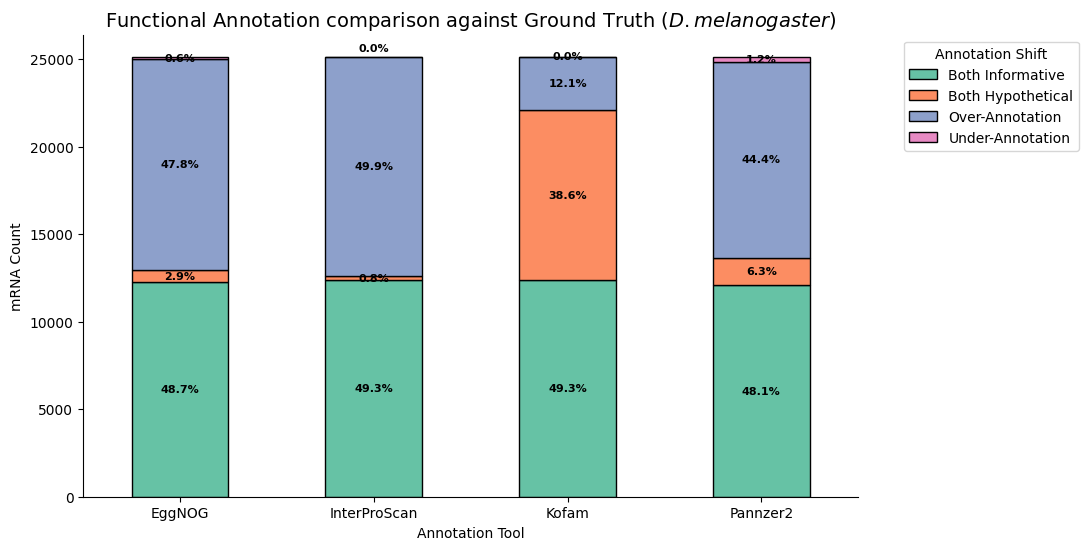

In [16]:
custom_color_map = {
    'Both Informative': '#66c2a5',  
    'Both Hypothetical': '#fc8d62',
    'Over-Annotation': '#8da0cb',  
    'Under-Annotation': '#e78ac3'    
}
summary_table.plot(kind='bar', stacked=True, figsize=(10, 6), color=[custom_color_map[cat] for cat in summary_table.columns], edgecolor='black')
plt.title("Functional Annotation comparison against Ground Truth ($\it{D. melanogaster}$)", fontsize=14)
for loc, spine in plt.gca().spines.items():
    if loc in ("bottom", "left"):
        spine.set_visible(True)
    else:
        spine.set_visible(False)
plt.ylabel("mRNA Count")
plt.xlabel("Annotation Tool")
plt.xticks(rotation=0)
plt.legend(title="Annotation Shift",
           bbox_to_anchor=(1.05, 1),
           loc='upper left')
total = summary_table.sum(axis=1).iloc[0]
ax = plt.gca()


for idx, container in enumerate(ax.containers):
    labels = [f'{v/total*100:.1f}%' for v in container.datavalues]
    text_objs = ax.bar_label(container, labels=labels,
                             label_type='center',
                             fontsize=8,
                             fontweight='bold')
    if idx == 3:
        text_objs[1].set_y(text_objs[1].get_position()[1] + 6)



In [17]:
def is_informative(product_text):
    if pd.isna(product_text):
        return False
       
    text = str(product_text).lower().strip()
   
    vague_terms = ['hypothetical', 'uncharacterized', 'unknown', 'putative', 'duf', 'DUF', 'domain of unknown function']
   
    if any(term in text for term in vague_terms) or text == '':
        return False
   
    return True

merged_df = merge_all.fillna("Don't have description")

tools = ['Reference', 'Kofam', 'Pannzer2', 'EggNOG', 'InterProScan']
for tool in tools:
    col_name = f'{tool}_description'
    info_col = f'is_info_{tool}'
    merged_df[info_col] = merged_df[col_name].apply(is_informative)


comparison_results = []
tools_to_evaluate = ['Kofam', 'EggNOG', 'Pannzer2', 'InterProScan']


for tool in tools_to_evaluate:
    tool_info = merged_df[f'is_info_{tool}']
    ref_info = merged_df['is_info_Reference']
   
    for i in range(len(merged_df)):
        t_val = tool_info.iloc[i]
        r_val = ref_info.iloc[i]
       
        if t_val == True and r_val == True:
            category = 'Both Informative'
        elif t_val == False and r_val == False:
            category = 'Both Hypothetical'
        elif t_val == True and r_val == False:
            category = 'Over-Annotation'
        elif t_val == False and r_val == True:
            category = 'Under-Annotation'
           
        comparison_results.append({
            'Tool': tool,
            'Category': category
        })


df_plot = pd.DataFrame(comparison_results)
summary_table = df_plot.groupby(['Tool', 'Category']).size().unstack(fill_value=0)


col_order = ['Both Informative', 'Both Hypothetical', 'Over-Annotation', 'Under-Annotation']
summary_table = summary_table[col_order]


print("--- Resumo Funcional: Ferramenta vs Referência ---")
display(summary_table)

KeyError: 'Reference_description'